# Comaparación de rentabilidad y volatilidad

Este archivo realiza una comparación entre fondos y acciones sobre la relación en tre rentabilidad y volatilidad. Incluye pasos como carga de datos, limpieza, análisis estadístico y visualización de resultados.

## Importación de Librerías

Se importan las librerías necesarias para el análisis: `pandas` y `numpy`.

In [1]:
import pandas as pd
import numpy as np

## Carga de Datos

Cargamos los datos desde archivos Excel utilizando pandas. 

Por un lado guardamos los fondos y por otro las acciones

In [ ]:
df_acciones = pd.read_excel('../data/Volatilidad_rentabilidad.xlsx', header= [0,1], index_col= 0)
df_fondos = pd.read_excel('../data/Excel_final_fondos.xlsx',index_col= 0)

# Limpieza de Datos

Borramos las filas de las acciones que no tienen todos los datos de 2020. Para ello:
- Reemplazamos los valores de 0 por NaN.
- Si la rentabilidad tanto de enero como de febrero de 2020 es nula, eliminamos la fila

In [3]:
cols = [('RENTABILIDAD', 'Jan 2020'), ('RENTABILIDAD', 'Feb 2020')]
df_acciones[cols] = df_acciones[cols].replace(0, np.nan)
df_acciones = df_acciones.dropna(subset=cols, how = 'all')
df_acciones.reset_index(drop=True, inplace= True)

Hacemos lo mismo con los fondos, donde los nulos son guiones

In [4]:
df_fondos.replace("-", np.nan, inplace= True)
df_fondos.dropna(subset=['rent 2020'], inplace= True)
df_fondos.reset_index(drop=True, inplace= True)

Eliminamos las columnas que no nos interesan

In [5]:
df_fondos.drop(columns= ['PRECIO PARTICIPACIÓN', 'rent 2019', 'rent 2018', 'rent 2017', 'Gasto De Gestión Max Anual'], inplace= True)

## Importación de Recursos

Se importa el recurso `reduce` de la librería `functools`.

In [6]:
from functools import reduce

# Preparación de los Datos

#### Función: `rentab_neta_5_años`

Esta función calcula la rentabilidad acumulada neta de un fondo durante un periodo de 5 años, teniendo en cuenta las comisiones anuales.

##### Pasos que realiza:
1. **Recorre los años entre 2020 y 2024**:
   - Calcula la rentabilidad neta para cada año, restando los gastos corrientes.
   - Almacena los factores de crecimiento en una lista.

2. **Multiplica los factores de crecimiento**:
   - Usa la multiplicación acumulada (reduce) para obtener el crecimiento total neto del fondo.
   - Resta 1 al producto total para expresar el crecimiento como decimal acumulado.

##### Retorna:
- La rentabilidad acumulada neta en forma decimal.


In [7]:

def rentab_neta_5_años(row) -> float:
    '''
    Calculo la rentabilidad acumulada de un fondo. Tengo en cuenta las comisiones anuales y 
    el incremento proporcionado por la reinversión
    '''
    productorio = []
    for i in range(2020, 2025):
        # Calculo la rentabilidad neta
        rentab_neta  = (1 + row[f'rent {i}']) * (1 - row['Gastos Corrientes'])
        # Lo añado a la lista
        productorio.append(rentab_neta)
    
    # Multiplico los factores de crecimiento y le resto uno para quedarme con el porcentaje de crecimiento.
    producto_total = reduce(lambda x,y: x*y, productorio) - 1
    return producto_total

Calculamos la rentabilidad neta de cada fondo desde 2020, es decir, desde hace 5 años


In [8]:
value_5_años = df_fondos.apply(lambda row: rentab_neta_5_años(row), axis = 1)
df_fondos.insert(7, 'rent neta', value_5_años)

Elegimos a los 50 fondos con **más rentabilidad neta** en los últimos 5 años

In [9]:
fondos_50_rent = df_fondos.sort_values(by= 'rent neta', ascending= False).iloc[:50, :]

Buscamos los valores máximo y mínimo de las rentabilidades de dichos fondos, y cogemos todas las acciones que tengan una rentabilidad que esté en ese intervalo.

In [10]:
max_fondos = fondos_50_rent['rent neta'].max()
min_fondos = fondos_50_rent['rent neta'].min()

acc_rent_5años = df_acciones[('RENTABILIDAD', 'Rentabilidad 5 años')]
acciones_selec1 = df_acciones[ (acc_rent_5años >= min_fondos) & (acc_rent_5años <= max_fondos)]

Por otro lado elegimos los 50 fondos con **más volatilidad** en los últimos 5 años

In [11]:
fondos_50_vol = df_fondos.sort_values(by= 'rent neta', ascending= False).iloc[:50, :]

Buscamos los valores máximo y mínimo de las volatilidades de dichos fondos, y cogemos todas las acciones que tengan una volatilidad que esté en ese intervalo

In [12]:
max_fondos = fondos_50_vol['Volatilidad'].max()
min_fondos = fondos_50_vol['Volatilidad'].min()

acc_vol_5_años = df_acciones[('VOLATILIDAD', '5 años')]
acciones_selec2 = df_acciones[ (acc_vol_5_años >= min_fondos) & (acc_vol_5_años <= max_fondos)]

Volvemos a pasar los datos a porcentajes para que sea más visual en las gráficas

In [13]:
fondos_50_rent.iloc[:, 7:11] = fondos_50_rent.iloc[:, 7:11].apply(lambda x: x*100)
fondos_50_vol.iloc[:, 7:11] = fondos_50_vol.iloc[:, 7:11].apply(lambda x: x*100)

cols = [('RENTABILIDAD', 'Rentabilidad 5 años'), ('VOLATILIDAD', '5 años')]
acciones_selec1.loc[:, cols] = acciones_selec1[cols].apply(lambda x: x*100)
acciones_selec2.loc[:, cols] = acciones_selec2[cols].apply(lambda x: x*100)

## Importación de Librerías

Se importan las librerías necesarias para la visualización: `matplotlib.pyplot`.

In [14]:
import matplotlib.pyplot as plt

# Visualización de los datos obtenidos

### Gráfico: Comparación de Volatilidad entre Fondos y Acciones con Rentabilidad Similar

Este gráfico compara la volatilidad de fondos y acciones que pertenecen al mismo rango de rentabilidad neta. 

Tenemos:
- Fondos azules: Los 50 fondos más rentables
- Acciones rojas: Acciones con la misma rentabilidad que los fondos más rentables (azules)

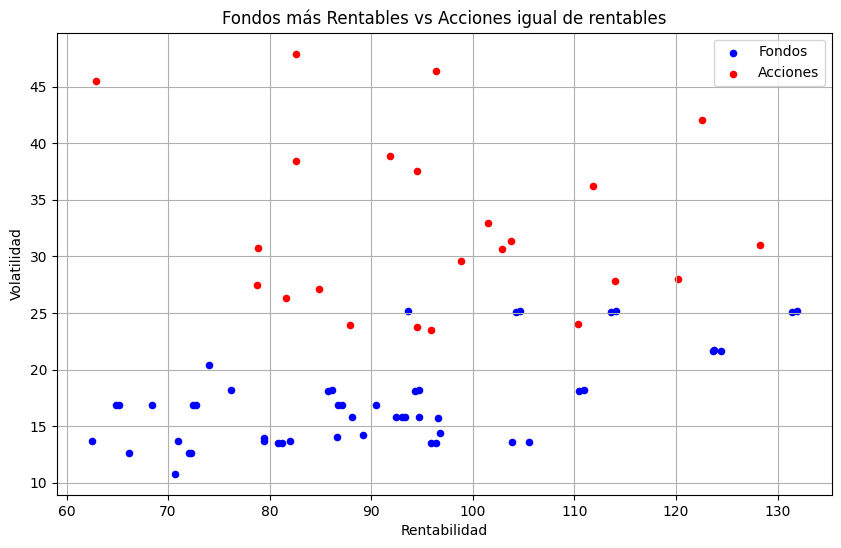

In [15]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

fondos_50_rent.plot(kind = 'scatter',
                x = 'rent neta', 
                y = 'Volatilidad',
                label='Fondos', 
                color='blue',
                ax = ax)

acciones_selec1.plot(kind = 'scatter', 
                    x = ('RENTABILIDAD', 'Rentabilidad 5 años'), 
                    y= ('VOLATILIDAD', '5 años'),
                    label='Acciones', 
                    color='red',
                    ax = ax)


ax.set_title('Fondos más Rentables vs Acciones igual de rentables')
ax.set_xlabel('Rentabilidad')
ax.set_ylabel('Volatilidad')
ax.legend()
ax.grid(True)

### Gráfico: Comparación de Rentabilidad entre Fondos y Acciones con Volatilidad Similar

Este gráfico compara la rentabilidad de fondos y acciones que se encuentran en el mismo rango de volatilidad. 

Tenemos:
- Fondos azules: Los 50 fondos más rentables
- Acciones rojas: Acciones con la misma volatilidad que los fondos más rentables (azules)

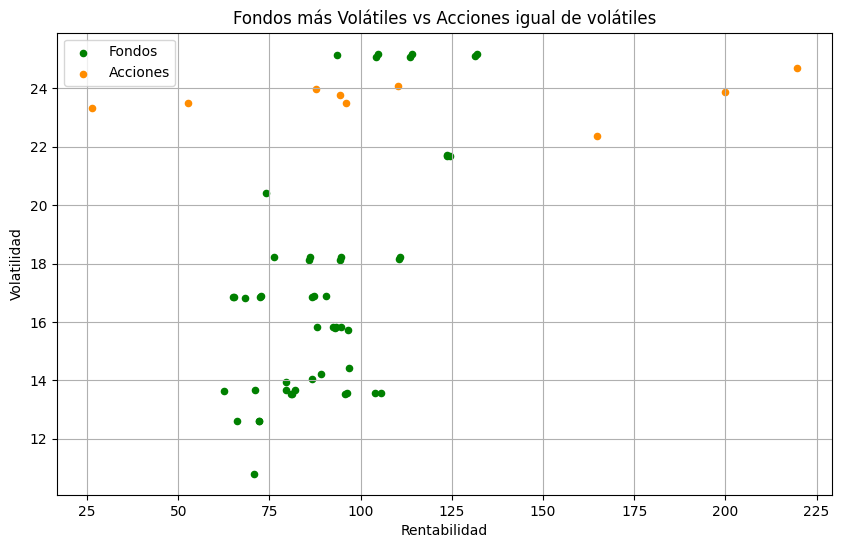

In [16]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

fondos_50_vol.plot(kind = 'scatter',
                x = 'rent neta', 
                y = 'Volatilidad',
                label='Fondos', 
                color='green',
                ax = ax)

acciones_selec2.plot(kind = 'scatter', 
                    x = ('RENTABILIDAD', 'Rentabilidad 5 años'), 
                    y= ('VOLATILIDAD', '5 años'),
                    label='Acciones',
                    color='darkorange',
                    ax = ax)

ax.set_title('Fondos más Volátiles vs Acciones igual de volátiles')
ax.set_xlabel('Rentabilidad')
ax.set_ylabel('Volatilidad')
ax.legend()
ax.grid(True)